<a href="https://colab.research.google.com/github/hania-sajjad/WEEK-4-TASK/blob/main/notebooks/week4_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT LIBRARIES
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# Evaluation
from sklearn.metrics import silhouette_score

# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.style.use("default")
sns.set_theme(style="whitegrid")

## Dataset

The dataset contains behavioral information of approximately 9,000 active credit card holders over a period of six months.

The first step is to load the dataset and inspect its structure, including the number of rows, columns, data types, and sample records.

In [2]:
# LOAD DATASET
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Data/CustomerData_Week4.csv")

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
# SHAPE OF DATASET
print("Dataset Shape:", df.shape)

# COLUMNS IN DATASET
print("\nColumns:")
print(df.columns)

# DATA TYPES OF COLUMNS
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (8950, 18)

Columns:
Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

Data Types:
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_

## Remove Customer ID

The **CUST_ID** column uniquely identifies each customer but does not contain useful information for clustering.

Since clustering algorithms rely on numerical feature similarity, identifier columns should be removed to avoid introducing unnecessary information into the model.

In [5]:
# REMOVE COLUMN (CUST_ID)
df = df.drop("CUST_ID", axis=1)

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Check Missing Values

Before applying any clustering algorithm, it is important to inspect the dataset for missing values.

Missing values can negatively affect distance-based algorithms such as K-Means because they prevent the calculation of distances between observations. Therefore, they must be handled appropriately before proceeding.

In [6]:
# CHECK MISSING VALUES
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313


## Handling Missing Values

The dataset contains missing values in a small number of numerical features.

Since these features are continuous variables, the missing values are replaced using the **median** of each column. The median is preferred because it is less sensitive to extreme values and outliers than the mean, making it a robust choice for financial data.

In [7]:
# FILL WITH MEDIAN
df = df.fillna(df.median(numeric_only=True))

# VERIFY THAT ALL VALUES HAVE BEEN HANDLED
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Feature Scaling

Clustering algorithms calculate the similarity between observations using distance measures such as Euclidean distance.

The features in this dataset have different units and ranges. For example, **BALANCE** may contain values in thousands, while **PURCHASES_FREQUENCY** ranges only between 0 and 1.

Without scaling, features with larger numerical values would dominate the distance calculations, resulting in biased clusters.

To ensure that every feature contributes equally, all variables are standardized using **StandardScaler**, which transforms each feature to have a mean of 0 and a standard deviation of 1.

In [8]:
# INITIALIZE THE SCALAR
scaler = StandardScaler()

# SCALE THE DATASET
scaled_data = scaler.fit_transform(df)

# CONVERT BACK TO DATAFRAME
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


## K-Means Clustering

The K-Means algorithm partitions the dataset into **K clusters** by minimizing the within-cluster variation.

Since the optimal number of clusters is unknown, the algorithm will be executed for values of **K ranging from 2 to 10**. The inertia (Within-Cluster Sum of Squares) will be recorded for each value to identify the most appropriate number of clusters.

In [9]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    inertia.append(kmeans.inertia_)

## Elbow Method

The Elbow Method helps determine the optimal number of clusters by plotting the inertia against different values of **K**.

As the number of clusters increases, inertia decreases. The ideal value of **K** is typically located at the point where the decrease in inertia begins to slow significantly, forming an "elbow" in the graph.

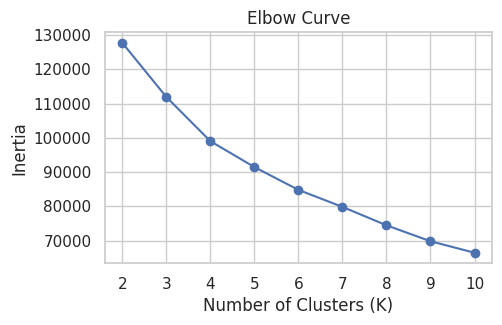

In [10]:
plt.figure(figsize=(5,3))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(k_values)

plt.show()

### Observation

From the Elbow Curve, the inertia decreases rapidly for smaller values of **K** and then begins to flatten.

The point where the curve noticeably bends represents the optimal number of clusters, as adding additional clusters beyond this point provides only marginal improvements.

## Silhouette Analysis

Although the Elbow Method provides a visual estimate of the optimal number of clusters, it may not always produce a clear answer.

The **Silhouette Score** measures how well each observation fits within its assigned cluster compared to neighboring clusters.

- A score close to **1** indicates well-separated clusters.
- A score near **0** indicates overlapping clusters.
- A negative score suggests incorrect clustering.

The value of **K** with the highest silhouette score is generally considered the best clustering solution.

In [11]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_df)

    score = silhouette_score(
        scaled_df,
        labels
    )

    silhouette_scores.append(score)

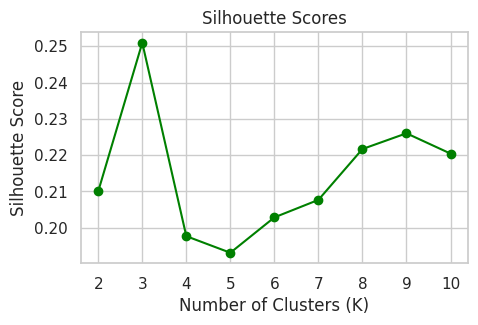

In [12]:
plt.figure(figsize=(5,3))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    color="green"
)

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)

plt.show()

### Observation

The optimal number of clusters is selected by considering both the Elbow Method and the Silhouette Score.

If both methods indicate the same value of **K**, it increases confidence that the chosen clustering solution provides meaningful customer segments.

## Final K-Means Clustering

Based on the Elbow Method and Silhouette Analysis, the optimal number of clusters is selected.

The K-Means algorithm is now trained using this value of **K**, and each customer is assigned to a cluster for further analysis.

In [13]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

df["Cluster"] = clusters

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


In [14]:
# NUMBER OF CUSTOMERS IN EACH CLUSTER
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,1275
1,6114
2,1561


## Cluster Profiling

To understand the characteristics of each customer segment, the mean value of every feature is calculated for each cluster.

These average values help identify behavioral differences among customer groups and provide meaningful business insights.

In [15]:
cluster_profile = df.groupby("Cluster").mean()

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2182.352833,0.981702,4187.017796,2663.995153,1523.493231,449.753140,0.948175,0.664780,0.739630,0.062415,1.507451,55.692549,7642.784314,4075.533648,1227.915879,0.298766,11.916863
1,807.722510,0.834577,496.062522,247.273214,249.110368,338.996760,0.460353,0.129191,0.342052,0.069563,1.236833,8.480046,3267.022176,907.446164,530.068546,0.154115,11.475793
2,4023.788865,0.959193,389.051448,252.333261,136.797412,3917.254973,0.233899,0.111806,0.145661,0.451410,12.551570,5.636131,6729.471201,3053.943771,1765.204181,0.033673,11.353619


## Cluster Heatmap

A heatmap is used to visualize the average feature values across all clusters.

This allows us to easily compare customer groups and identify distinguishing characteristics such as spending behavior, payment patterns, credit limits, and cash advance usage.

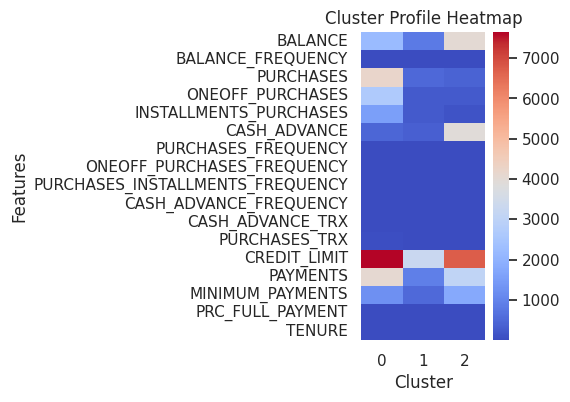

In [26]:
plt.figure(figsize=(2,4))

sns.heatmap(
    cluster_profile.T,
    cmap="coolwarm",
    annot=False
)

plt.title("Cluster Profile Heatmap")

plt.xlabel("Cluster")
plt.ylabel("Features")

plt.show()

## Cluster Interpretation

Based on the average feature values of each cluster, the customers can be grouped into three distinct segments:

### Cluster 0 – High Spenders

Customers in this cluster have the highest purchase amounts, frequent purchases, and high credit limits. They also maintain relatively high balances while making regular payments and often pay a significant portion of their balance in full.

These customers represent loyal and valuable customers who actively use their credit cards for everyday and high-value purchases.

---

### Cluster 1 – Low Activity Customers

Customers in this cluster have the lowest balances, purchase amounts, and transaction counts. They also have lower credit limits and relatively small payment amounts.

This group represents occasional credit card users who use their cards infrequently and generally maintain low account activity.

---

### Cluster 2 – Cash Advance Users

Customers in this cluster have the highest balances and extremely high cash advance amounts. They also perform the largest number of cash advance transactions while making comparatively fewer purchases.

These customers appear to rely heavily on cash advances instead of regular purchases, making them a potentially higher-risk customer segment from a financial perspective.

---

Overall, the clustering process successfully separates customers into meaningful business segments that can support personalized marketing campaigns, customer relationship management, and risk assessment.

## Hierarchical Clustering

Unlike K-Means, Hierarchical Clustering does not require clusters to be formed iteratively around centroids. Instead, it builds a hierarchy of clusters by repeatedly merging the closest observations.

To reduce computational complexity and improve visualization, a random sample of **300 customers** is selected from the scaled dataset.

In [17]:
# RANDOMLY SAMPLE 300 OBSERVATIONS
sample_df = scaled_df.sample(
    n=300,
    random_state=42
)

sample_df.shape

(300, 17)

## Dendrogram

A dendrogram is a tree-like diagram that illustrates how observations are merged during hierarchical clustering.

The horizontal threshold line indicates the level at which the dendrogram is cut to obtain the desired number of clusters.

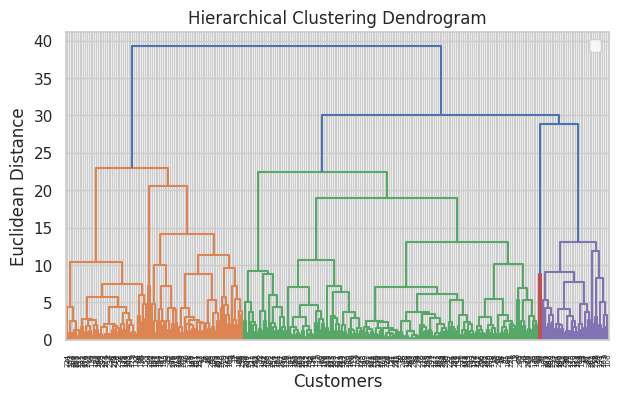

In [22]:
# WITHOUT RED LINE
plt.figure(figsize=(7,4))

linked = linkage(
    sample_df,
    method="ward"
)

dendrogram(
    linked,
    truncate_mode=None
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.legend()

plt.show()

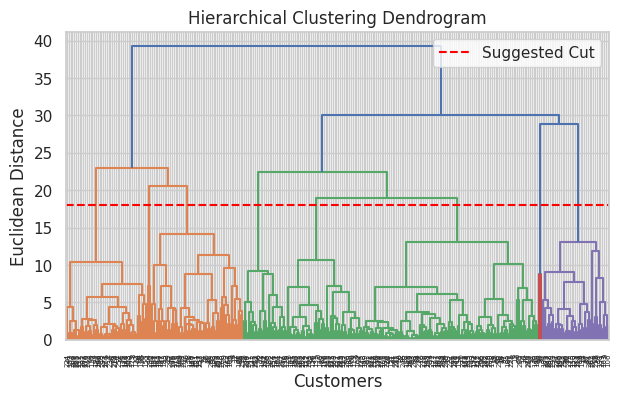

In [23]:
# WITH RED LINE
plt.figure(figsize=(7,4))

linked = linkage(
    sample_df,
    method="ward"
)

dendrogram(
    linked,
    truncate_mode=None
)

plt.axhline(
    y=18,
    color="red",
    linestyle="--",
    label="Suggested Cut"
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.legend()

plt.show()

## Agglomerative Clustering

Using the same number of clusters selected for K-Means allows a fair comparison between the two clustering techniques.

The Agglomerative Clustering algorithm is applied to the entire scaled dataset.

In [19]:
agglomerative = AgglomerativeClustering(
    n_clusters=3
)

agg_clusters = agglomerative.fit_predict(scaled_df)

df["Agglomerative_Cluster"] = agg_clusters

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster,Agglomerative_Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1,1


## Comparing Cluster Assignments

To evaluate the similarity between K-Means and Hierarchical Clustering, a cross-tabulation of their cluster assignments is created.

A strong diagonal pattern indicates that both algorithms assign many customers to similar clusters.

In [20]:
comparison = pd.crosstab(
    df["Cluster"],
    df["Agglomerative_Cluster"]
)

comparison

Agglomerative_Cluster,0,1,2
Cluster,,,
0,1162,94,19
1,1570,4414,130
2,149,367,1045


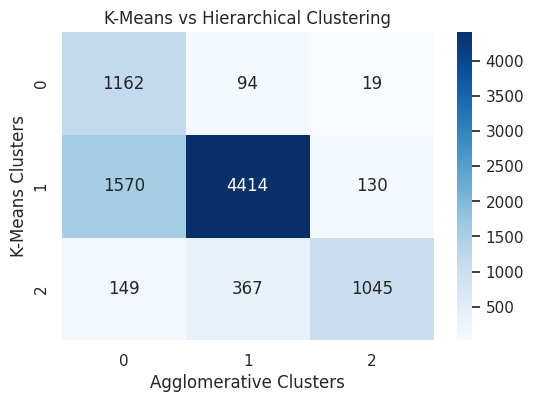

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(
    comparison,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("K-Means vs Hierarchical Clustering")

plt.xlabel("Agglomerative Clusters")
plt.ylabel("K-Means Clusters")

plt.show()

## Comparison Report

To evaluate the consistency between K-Means and Hierarchical Clustering, a cross-tabulation of their cluster assignments was performed.

The comparison shows that both algorithms produce broadly similar customer segments, with the majority of customers remaining in corresponding clusters. However, some customers are assigned to different clusters, indicating that the algorithms capture certain customer behaviors differently.

### K-Means Clustering

- Computationally efficient and well suited for large datasets.
- Produces compact, spherical clusters by minimizing within-cluster variance.
- Easy to implement and interpret.
- Ideal for customer segmentation when the approximate number of clusters is known.

### Hierarchical Clustering

- Does not require iterative centroid updates.
- Provides a dendrogram that helps visualize how clusters are formed.
- Useful for understanding relationships between observations.
- More computationally expensive for large datasets compared to K-Means.

### Recommendation

For this dataset, **K-Means is the recommended clustering algorithm**. It produced meaningful customer segments, is computationally efficient for datasets containing thousands of customers, and is easier to scale for real-world business applications.

Hierarchical Clustering serves as an excellent validation technique and provides additional insight into the relationships among customer groups through the dendrogram. However, due to its higher computational cost, it is generally more suitable for exploratory analysis or smaller datasets.

Overall, both algorithms successfully identified meaningful customer segments that can support targeted marketing, customer relationship management, and financial risk assessment.

## Conclusion

This project successfully applied two unsupervised machine learning techniques to segment credit card customers based on their financial behavior.

K-Means clustering was used to identify customer groups using the Elbow Method and Silhouette Score to determine the optimal number of clusters. The resulting customer segments represented high spenders, low activity customers, and cash advance users.

Hierarchical Clustering provided an alternative view of the same data and produced comparable customer groupings. Comparing both approaches helped validate the clustering results and demonstrated how different unsupervised learning algorithms can uncover meaningful patterns within financial datasets.

These customer segments can support targeted marketing campaigns, customer retention strategies, personalized financial products, and risk management, making clustering a valuable tool for business decision-making.